In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/MyDrive/Colab Notebooks/Exports.xlsx'
data = pd.read_excel(file_path, skiprows=5)

data.columns = ['Fiscal_Year', 'Quarter/Months', 'Food_and_Live', 'Tobacco', 'Crude_Materials',
                'Mineral_Fuels', 'Animal_and_Vegetable', 'Chemicals', 'Manufactured_Goods',
                'Machinery', 'Miscellaneous_Manufactured', 'Commodity']


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/Exports.xlsx'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Convert numerical columns to proper types and handle missing values
for col in data.columns[2:]:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Display initial information about the dataset
print(data.info())
print(data.head())

# Fill or drop missing values as appropriate
data.dropna(subset=['Fiscal_Year', 'Quarter/Months'], inplace=True)
data.fillna(0, inplace=True)


1. Yearly and Quarterly Trends

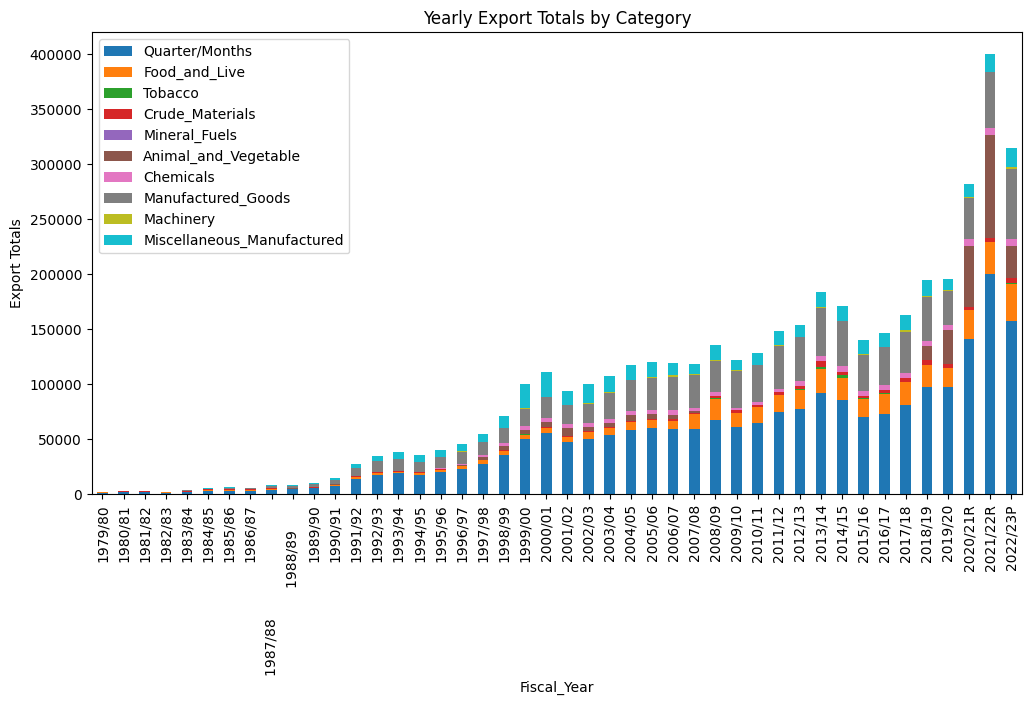

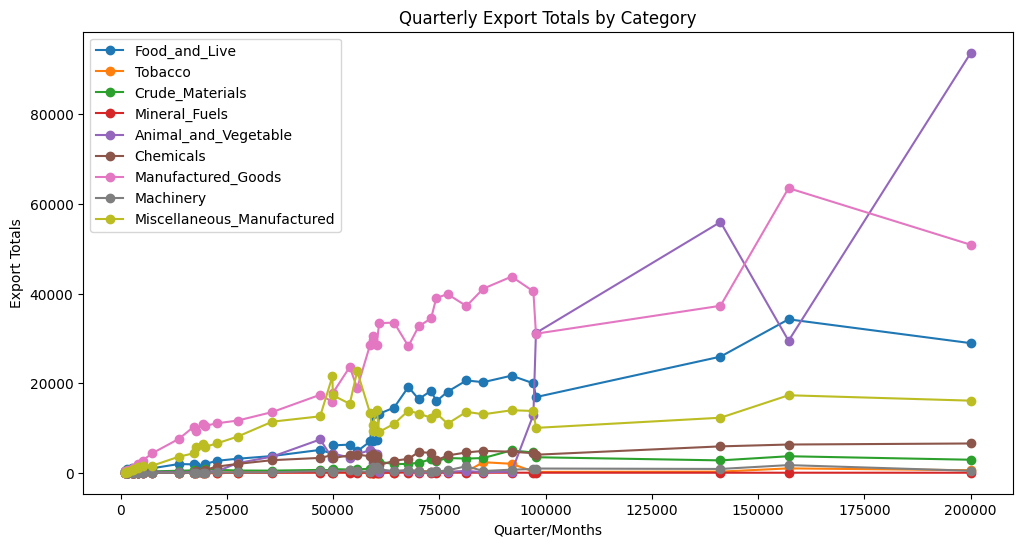

In [ ]:
# Yearly trends in total exports
yearly_totals = data.groupby('Fiscal_Year').sum().drop(columns=['Commodity'])
yearly_totals.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Yearly Export Totals by Category')
plt.ylabel('Export Totals')
plt.show()

# Quarterly trends
quarterly_totals = data.groupby('Quarter/Months').sum().drop(columns=['Commodity'])
quarterly_totals.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Quarterly Export Totals by Category')
plt.ylabel('Export Totals')
plt.show()


2. Commodity-Specific Analysis

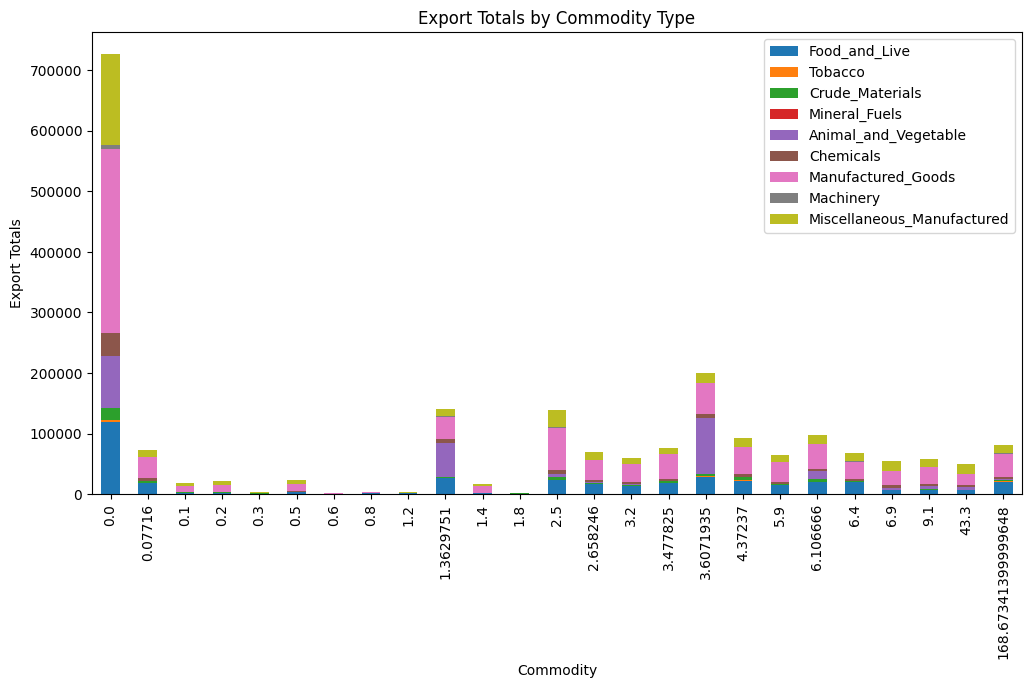

In [ ]:
# Total exports per commodity type
commodity_totals = data.groupby('Commodity').sum().drop(columns=['Fiscal_Year', 'Quarter/Months'])
commodity_totals.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Export Totals by Commodity Type')
plt.ylabel('Export Totals')
plt.show()


3. Commodity Trends Over Time

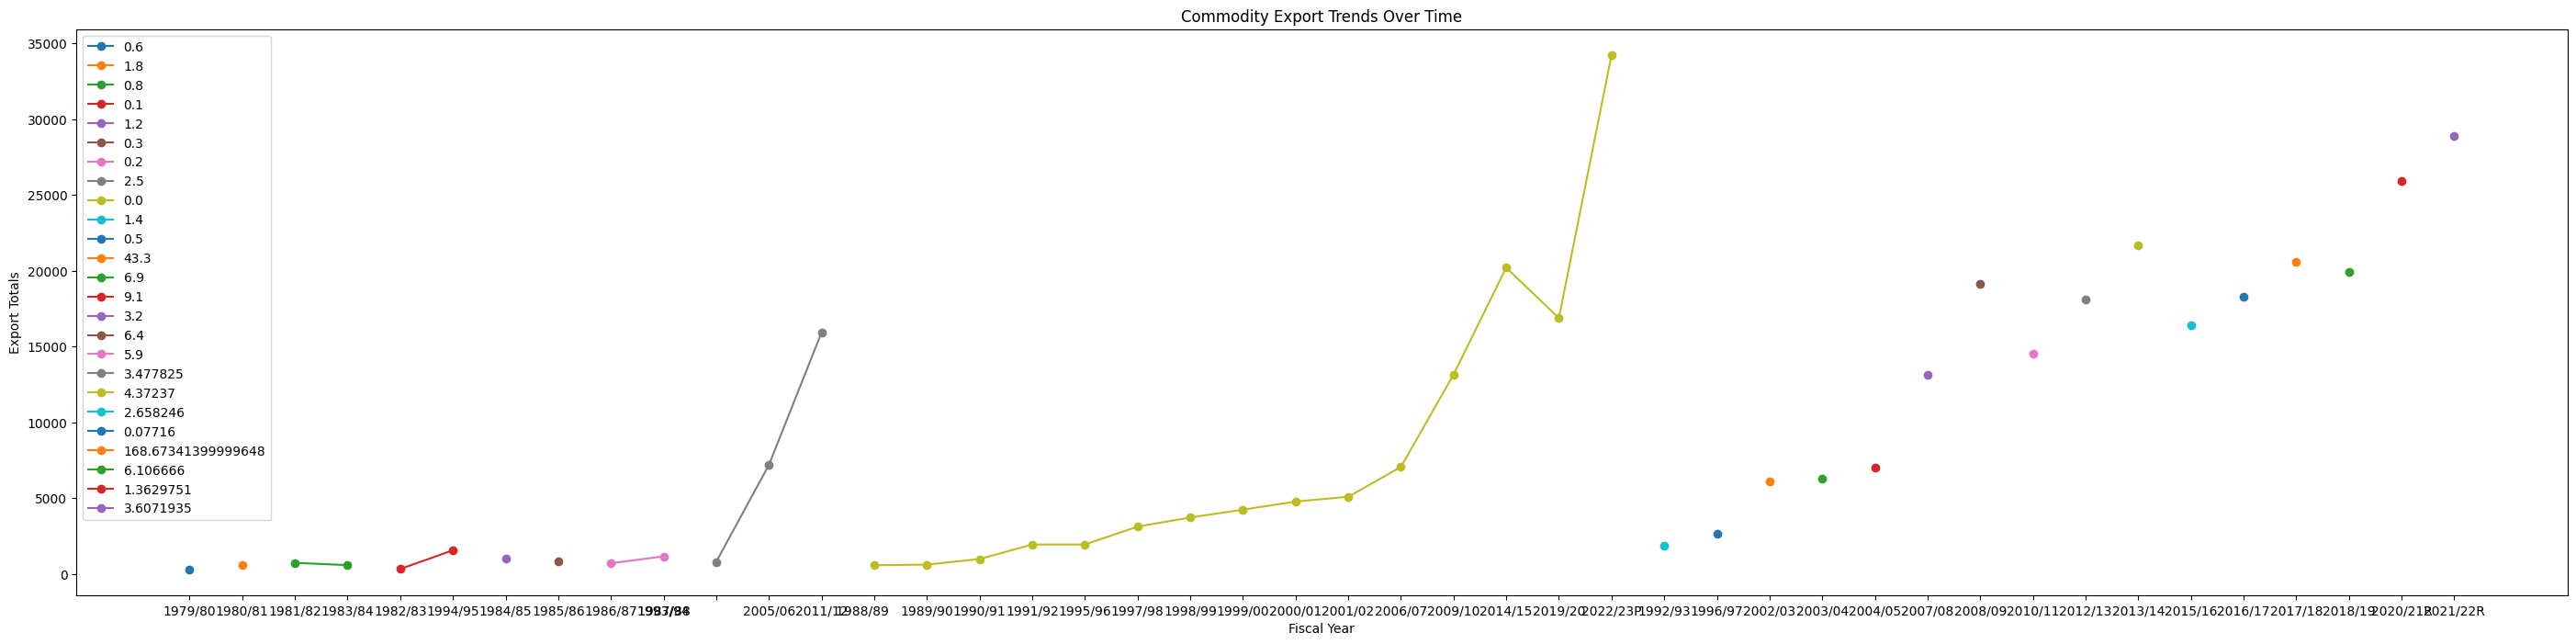

In [ ]:
# Line plot for trends over time for each commodity
plt.figure(figsize=(35, 8))
for commodity in data['Commodity'].unique():
    yearly_data = data[data['Commodity'] == commodity].groupby('Fiscal_Year').sum()
    plt.plot(yearly_data.index, yearly_data['Food_and_Live'], marker='o', label=commodity)

plt.title('Commodity Export Trends Over Time')
plt.xlabel('Fiscal Year')
plt.ylabel('Export Totals')
plt.legend()
plt.show()


4. Export Category Comparisons

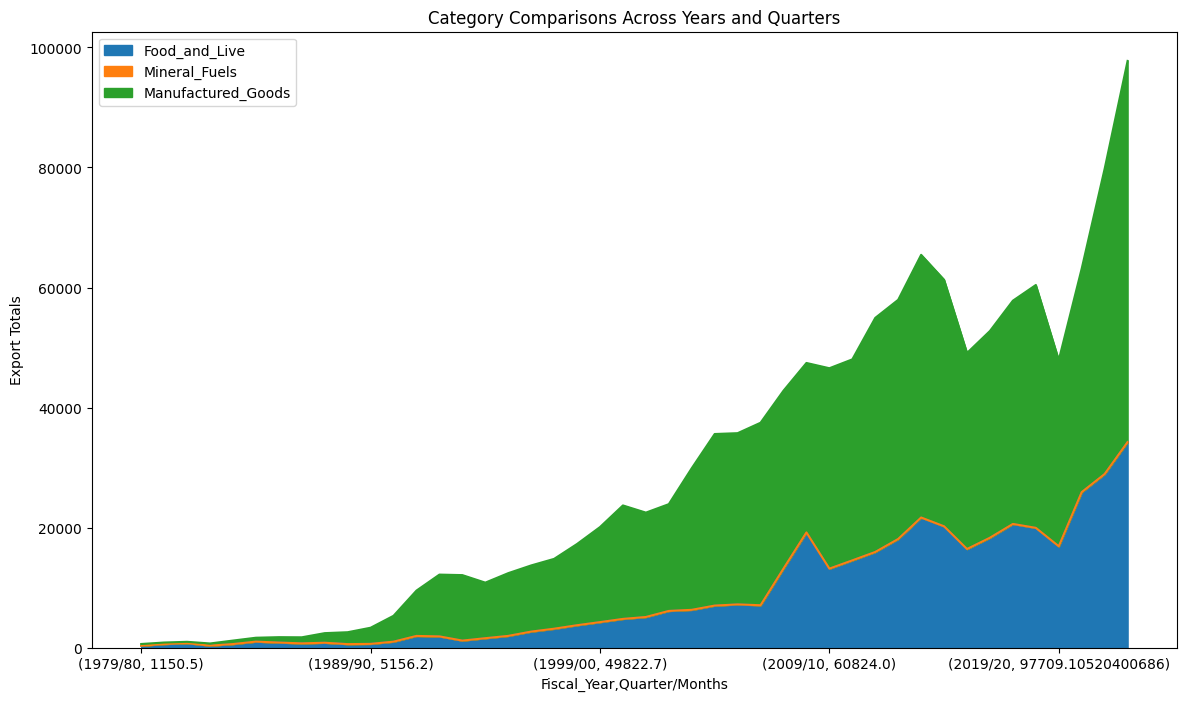

In [ ]:
# Comparing export categories over time
category_totals = data.groupby(['Fiscal_Year', 'Quarter/Months']).sum()
category_totals[['Food_and_Live', 'Mineral_Fuels', 'Manufactured_Goods']].plot(kind='area', stacked=True, figsize=(14, 8))
plt.title('Category Comparisons Across Years and Quarters')
plt.ylabel('Export Totals')
plt.show()


5. Top Commodities per Fiscal Year

In [ ]:
# Find top commodities each year
top_commodities = data.groupby('Fiscal_Year').apply(lambda x: x.nlargest(3, 'Food_and_Live'))
print(top_commodities)

# Plot top 3 commodities per year
for year in top_commodities['Fiscal_Year'].unique():
    subset = top_commodities[top_commodities['Fiscal_Year'] == year]
    plt.figure()
    sns.barplot(x=subset['Commodity'], y=subset['Food_and_Live'])
    plt.title(f'Top 3 Commodities in {year}')
    plt.show()


6. Seasonality Analysis

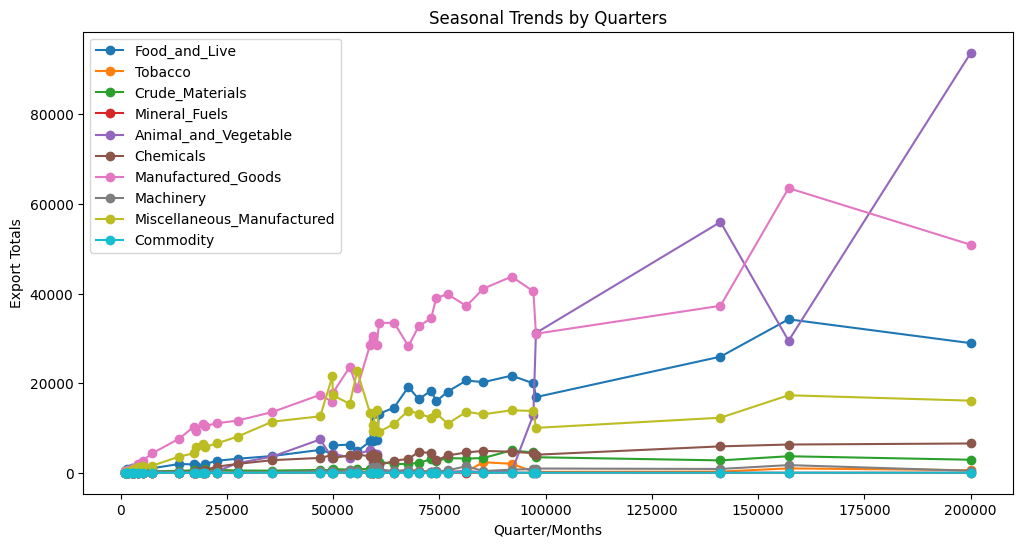

In [ ]:
# Seasonality analysis by quarters
quarterly_seasonality = data.groupby('Quarter/Months').sum()
quarterly_seasonality.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Seasonal Trends by Quarters')
plt.ylabel('Export Totals')
plt.show()


7. Correlation Analysis

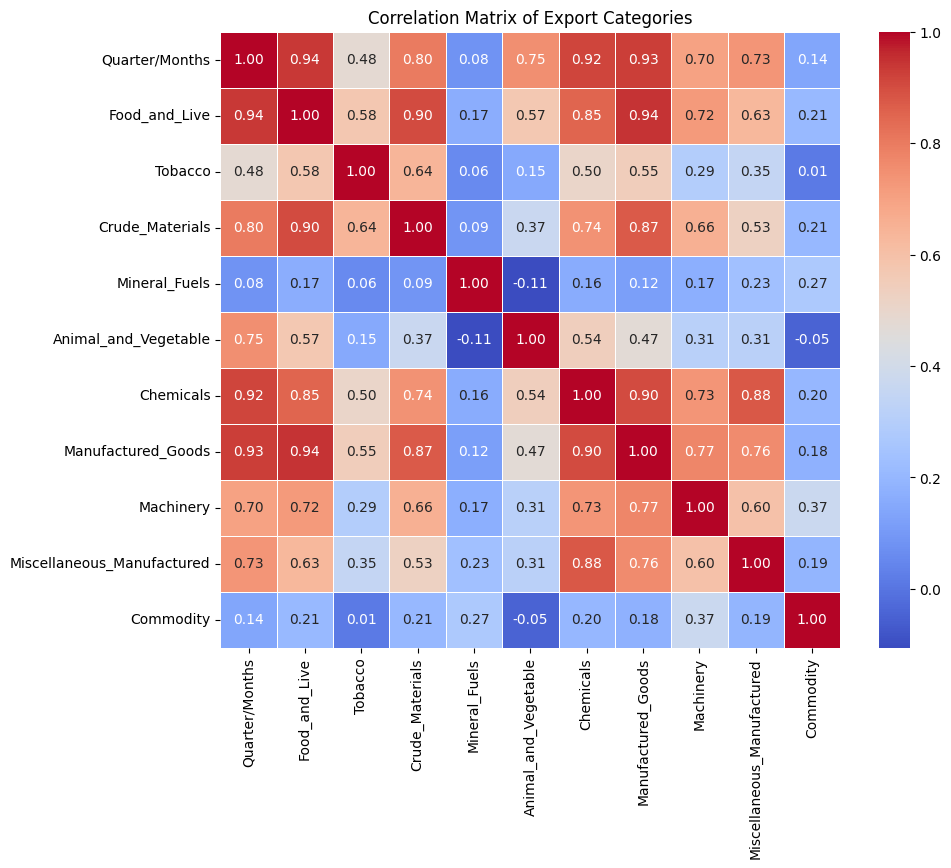

In [ ]:
# Select only numeric columns for correlation matrix calculation
numeric_data = data.select_dtypes(include=['number'])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Export Categories')
plt.show()

8. Missing Data Analysis

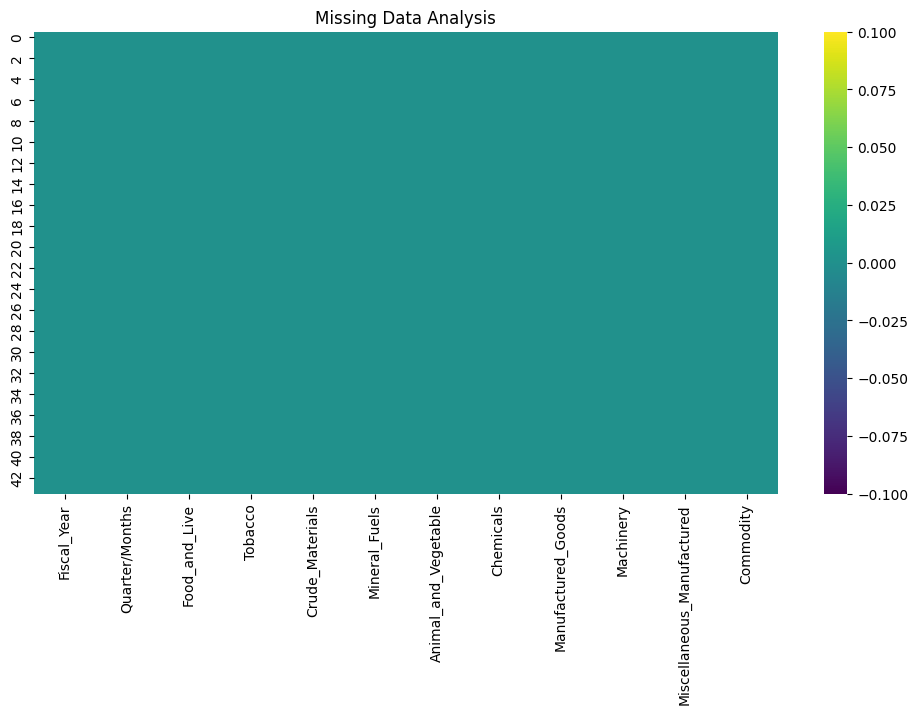

In [ ]:
# Display missing values heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=True, cmap='viridis')
plt.title('Missing Data Analysis')
plt.show()


9. Growth Rate Calculation

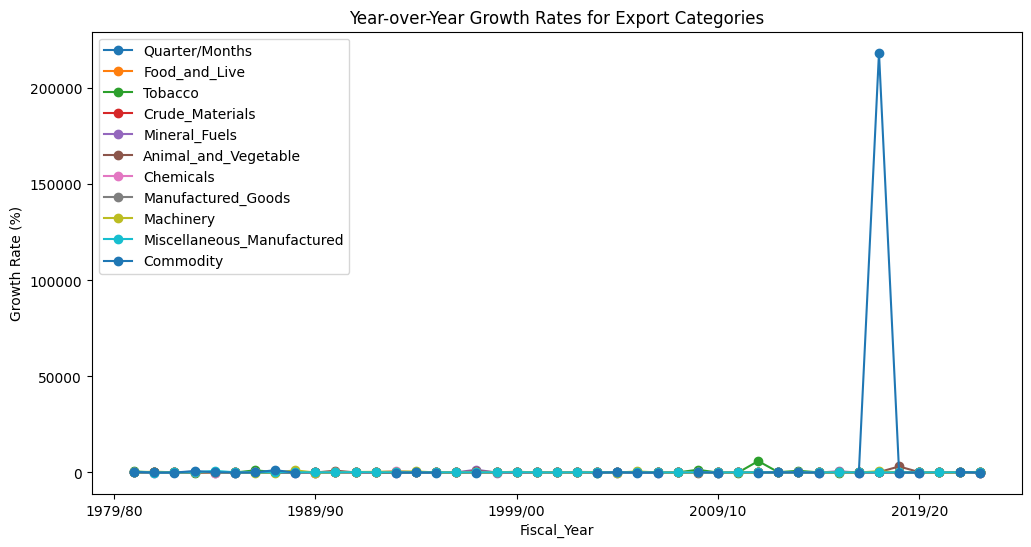

In [ ]:
# Calculate year-over-year growth for each category
growth_rates = data.groupby('Fiscal_Year').sum().pct_change() * 100
growth_rates.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Year-over-Year Growth Rates for Export Categories')
plt.ylabel('Growth Rate (%)')
plt.show()


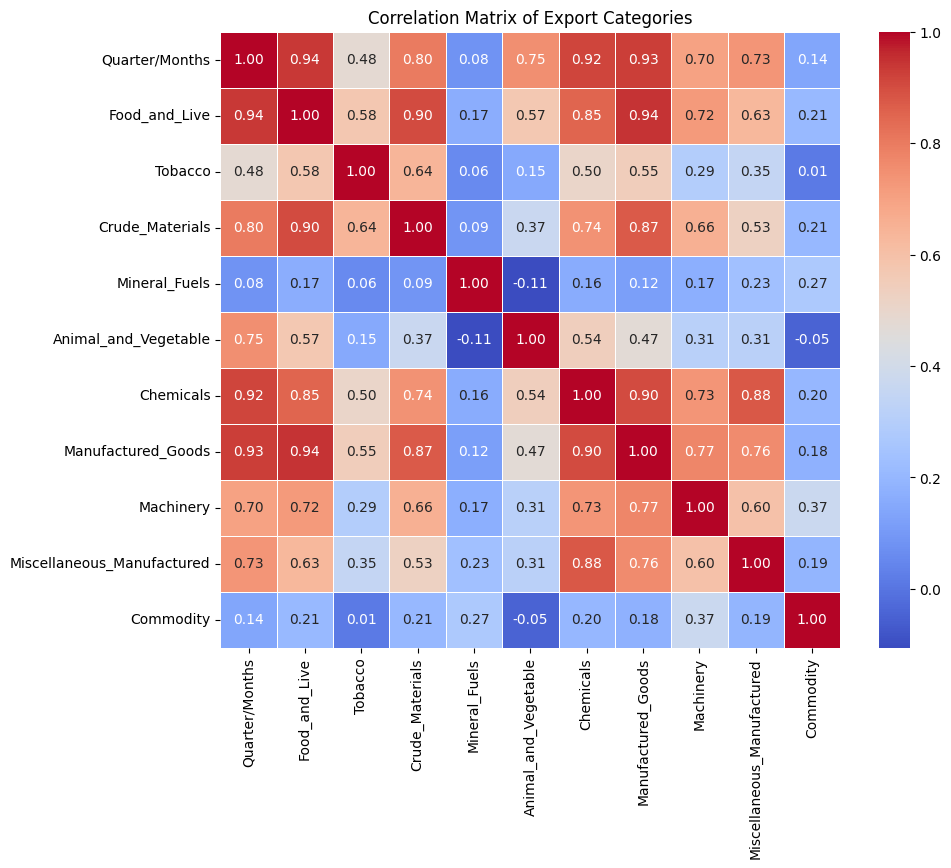

In [ ]:
# Select only numeric columns for correlation matrix calculation
numeric_data = data.select_dtypes(include=['number'])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Export Categories')
plt.show()

Poblem 1: High/Low Demand Classification

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         6
           1       1.00      0.62      0.77         8

    accuracy                           0.79        14
   macro avg       0.83      0.81      0.78        14
weighted avg       0.86      0.79      0.78        14



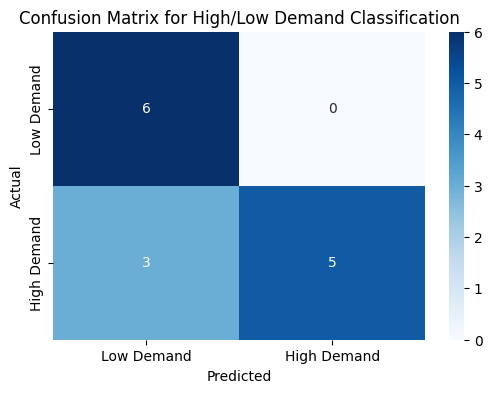

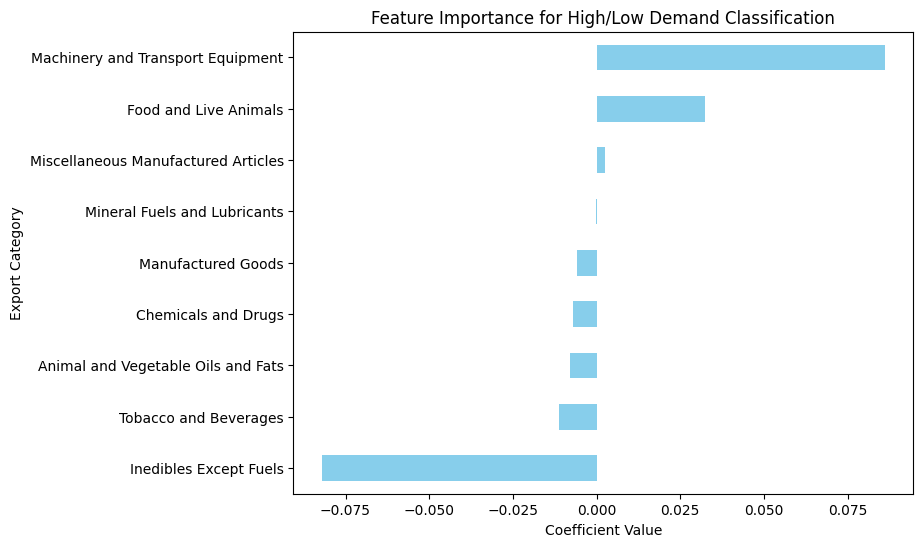

In [ ]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/Exports.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', header=4)

# Clean column names
df.columns = [
    "Fiscal Year/Quarter/Month", "Total", "Food and Live Animals", "Tobacco and Beverages",
    "Inedibles Except Fuels", "Mineral Fuels and Lubricants", "Animal and Vegetable Oils and Fats",
    "Chemicals and Drugs", "Manufactured Goods", "Machinery and Transport Equipment",
    "Miscellaneous Manufactured Articles", "Transactions not Classified"
]

# Drop non-data rows
df = df.dropna(subset=["Fiscal Year/Quarter/Month"]).reset_index(drop=True)

# Convert numerical columns to appropriate types
for column in df.columns[1:]:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Set binary target based on median of Total exports
median_export = df["Total"].median()
df['High_Demand'] = (df["Total"] >= median_export).astype(int)

# Define features (export categories) and target
X = df[["Food and Live Animals", "Tobacco and Beverages", "Inedibles Except Fuels",
        "Mineral Fuels and Lubricants", "Animal and Vegetable Oils and Fats", "Chemicals and Drugs",
        "Manufactured Goods", "Machinery and Transport Equipment", "Miscellaneous Manufactured Articles"]]
y = df['High_Demand']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Logistic Regression model
from sklearn.impute import SimpleImputer

# Impute missing values in X_train and X_test
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predict on test set
y_pred = log_reg.predict(X_test)


# Predict on test set
y_pred = log_reg.predict(X_test)

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Demand', 'High Demand'], yticklabels=['Low Demand', 'High Demand'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for High/Low Demand Classification")
plt.show()

# Extract and plot feature importance
feature_importance = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()

# Plot feature importance
plt.figure(figsize=(8, 6))
feature_importance.plot(kind='barh', color='skyblue')
plt.title("Feature Importance for High/Low Demand Classification")
plt.xlabel("Coefficient Value")
plt.ylabel("Export Category")
plt.show()


Problem 2: Identifying Seasonal and Trend Patterns using a Random Forest Regressor

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/Exports.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', header=4)

# Clean and rename columns
df.columns = [
    "Fiscal Year/Quarter/Month", "Total", "Food and Live Animals", "Tobacco and Beverages",
    "Inedibles Except Fuels", "Mineral Fuels and Lubricants", "Animal and Vegetable Oils and Fats",
    "Chemicals and Drugs", "Manufactured Goods", "Machinery and Transport Equipment",
    "Miscellaneous Manufactured Articles", "Transactions not Classified"
]
df = df.dropna(subset=["Fiscal Year/Quarter/Month"]).reset_index(drop=True)

# Convert numerical columns to the appropriate data type
for column in df.columns[1:]:
    df[column] = pd.to_numeric(df[column], errors='coerce')


print(df.columns)
df.rename(columns=lambda x: x.strip(), inplace=True)  # Remove any extra spaces in column names

# Extract year and month from the "Fiscal Year/Quarter/Month" column
# Fill any NaN values with a placeholder (e.g., 0) before converting to integers
df['Year'] = df["Fiscal Year/Quarter/Month"].str.extract(r"(\d{4})")[0].fillna(0).astype(int)
df['Month'] = df["Fiscal Year/Quarter/Month"].str.extract(r"/(\d{2})")[0].fillna(0).astype(int)

# Drop rows where either Year or Month is 0, as these indicate missing or improperly formatted data
df = df[(df['Year'] != 0) & (df['Month'] != 0)]


Index(['Fiscal Year/Quarter/Month', 'Total', 'Food and Live Animals',
       'Tobacco and Beverages', 'Inedibles Except Fuels',
       'Mineral Fuels and Lubricants', 'Animal and Vegetable Oils and Fats',
       'Chemicals and Drugs', 'Manufactured Goods',
       'Machinery and Transport Equipment',
       'Miscellaneous Manufactured Articles', 'Transactions not Classified'],
      dtype='object')


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Initialize and train the Random Forest Regressor model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
# Make predictions on the test set
y_pred = rf_regressor.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")


Mean Squared Error: 0.01
R-squared: 0.94


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


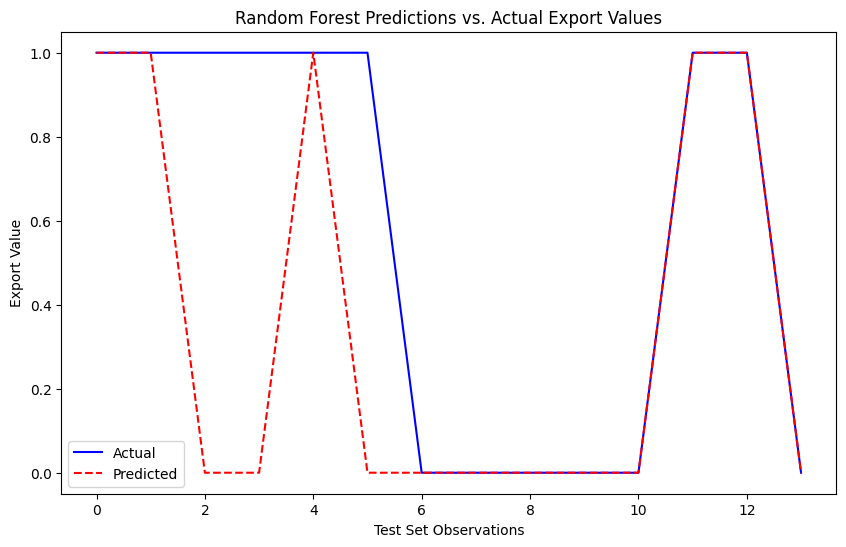

In [ ]:
# Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label="Actual", color="blue")
plt.plot(y_pred, label="Predicted", color="red", linestyle="--")
plt.xlabel("Test Set Observations")
plt.ylabel("Export Value")
plt.title("Random Forest Predictions vs. Actual Export Values")
plt.legend()
plt.show()


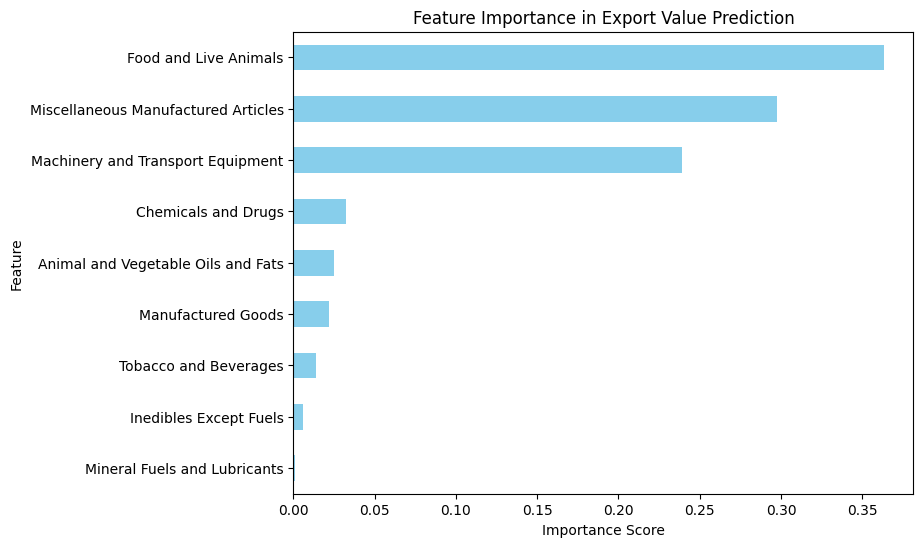

In [ ]:
# Feature importance plot
feature_importance = pd.Series(rf_regressor.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
feature_importance.plot(kind='barh', color='skyblue')
plt.title("Feature Importance in Export Value Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()
